In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/cleaned_data.csv")

df.head()

,patient_id,appointment_id,gender,scheduled_day,appointment_day,age,neighbourhood,welfare_support,hypertension,Diabetes,Alcoholism,disability,sms_received,no_show,waiting_days
0,9.598513e+13,5626772,F,2016-04-27 08:36:51+00:00,2016-04-29 00:00:00+00:00,76,REPÚBLICA,0,1,0,0,0,0,0,1
1,7.336882e+14,5630279,F,2016-04-27 15:05:12+00:00,2016-04-29 00:00:00+00:00,23,GOIABEIRAS,0,0,0,0,0,0,1,1
2,3.449833e+12,5630575,F,2016-04-27 15:39:58+00:00,2016-04-29 00:00:00+00:00,39,GOIABEIRAS,0,0,0,0,0,0,1,1
3,7.812456e+13,5629123,F,2016-04-27 12:48:25+00:00,2016-04-29 00:00:00+00:00,19,CONQUISTA,0,0,0,0,0,0,0,1
4,7.345362e+14,5630213,F,2016-04-27 14:58:11+00:00,2016-04-29 00:00:00+00:00,30,NOVA PALESTINA,0,0,0,0,0,0,0,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71959 entries, 0 to 71958
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   patient_id       71959 non-null  float64
 1   appointment_id   71959 non-null  int64  
 2   gender           71959 non-null  object 
 3   scheduled_day    71959 non-null  object 
 4   appointment_day  71959 non-null  object 
 5   age              71959 non-null  int64  
 6   neighbourhood    71959 non-null  object 
 7   welfare_support  71959 non-null  int64  
 8   hypertension     71959 non-null  int64  
 9   Diabetes         71959 non-null  int64  
 10  Alcoholism       71959 non-null  int64  
 11  disability       71959 non-null  int64  
 12  sms_received     71959 non-null  int64  
 13  no_show          71959 non-null  int64  
 14  waiting_days     71959 non-null  int64  
dtypes: float64(1), int64(10), object(4)
memory usage: 8.2+ MB


,patient_id,appointment_id,age,welfare_support,hypertension,Diabetes,Alcoholism,disability,sms_received,no_show,waiting_days
count,7.195900e+04,7.195900e+04,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000,71959.000000
mean,1.452606e+14,5.655042e+06,38.502564,0.092706,0.208897,0.074723,0.025320,0.020025,0.493086,0.285190,14.642018
std,2.535667e+14,7.472189e+04,22.925421,0.290021,0.406523,0.262946,0.157096,0.154072,0.499956,0.451508,16.494334
min,3.921784e+04,5.030230e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.968099e+12,5.617796e+06,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
50%,2.991891e+13,5.661165e+06,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
75%,9.371660e+13,5.707178e+06,57.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,21.000000
max,9.999320e+14,5.784985e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,178.000000


In [4]:
# No-show Rate
no_show_rate = df["no_show"].mean()
print(f"No-show rate: {no_show_rate:.2%}")

No-show rate: 28.52%


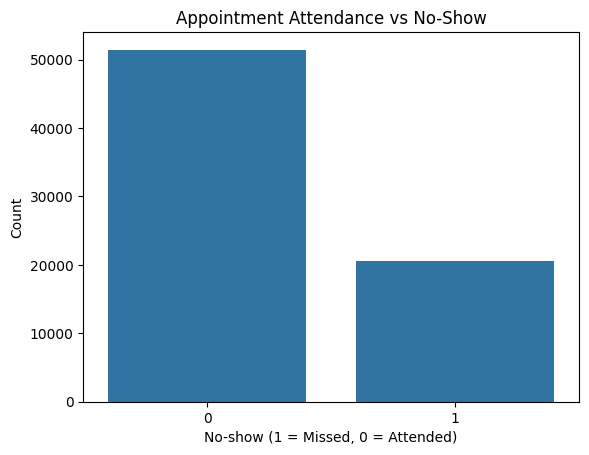

In [5]:
sns.countplot(x="no_show", data=df)
plt.title("Appointment Attendance vs No-Show")
plt.xlabel("No-show (1 = Missed, 0 = Attended)")
plt.ylabel("Count")
plt.show()

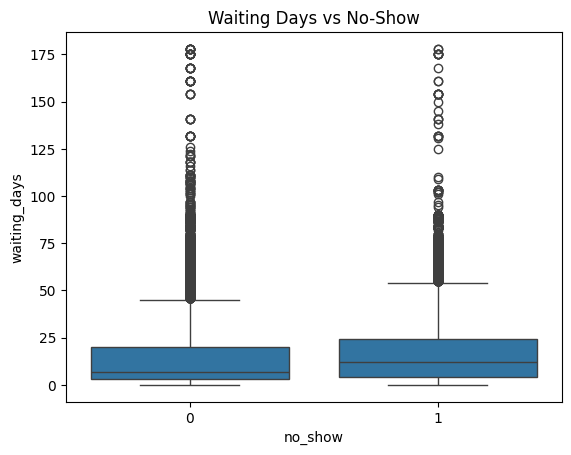

In [6]:
# Waiting Days Vs No-Show
sns.boxplot(x="no_show", y="waiting_days", data=df)
plt.title("Waiting Days vs No-Show")
plt.show()

Insight:
- Longer waiting time → higher no-show risk

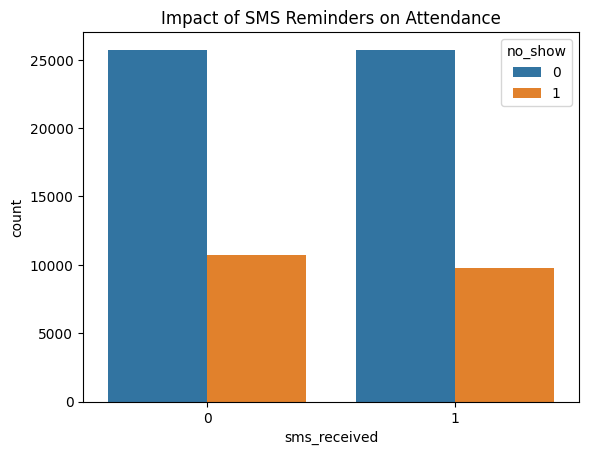

In [7]:
# SMS Reminder Impact
sns.countplot(x="sms_received", hue="no_show", data=df)
plt.title("Impact of SMS Reminders on Attendance")
plt.show()

Insight:
- Patients without SMS reminders tend to miss more appointments

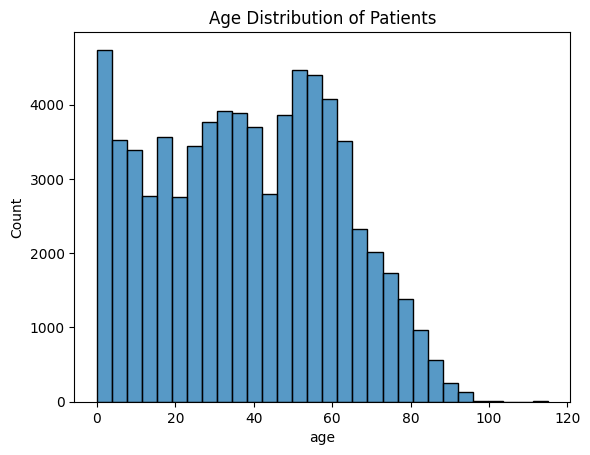

In [8]:
# Age Distribution
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution of Patients")
plt.show()

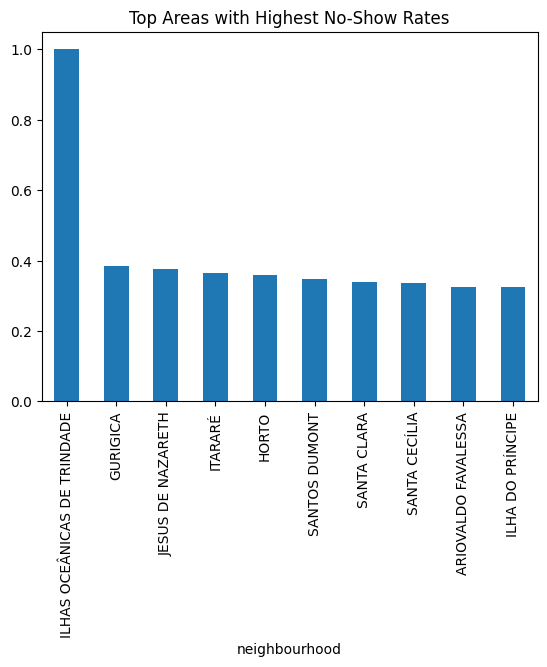

In [14]:
# Top Neighbourhoods with No-Shows
top_neighbourhoods = (
    df.groupby("neighbourhood")["no_show"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_neighbourhoods.plot(kind="bar")
plt.title("Top Areas with Highest No-Show Rates")
plt.show()


In [11]:
# Save Key Plots
plt.savefig("../images/no_show_distribution.png")

<Figure size 640x480 with 0 Axes>